
# AKATHON PROGRAMMING COMMUNITY by **AKAABO AKAADIDOO**
### Attendance Data Cleaning & Analysis (Pandas + Matplotlib)

**Objective:**  
This notebook cleans and analyzes an attendance Excel file using **pandas** and **matplotlib**.

## Tasks Covered
1. Aggregate attendance by Matriculation Number  
2. Compute attendance score (occurrence × 5)  
3. Order records by Department  
4. Export attendance files per department using Regular Expressions  
5. Perform and document multiple visualizations using matplotlib  

---
## *NOTE: This data has **not been cleaned properly** before visualization to emphasize the importance of Data Cleaning*
---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re


pd.set_option('display.max_columns', None)
pd.set_option('display.width',None)



## Step 1: Load the Attendance File
We load the Excel attendance file using pandas.


In [2]:
file_path = "attendance.xlsx"
df = pd.read_excel(file_path)

df.head()


,Timestamp,Email address,JAMB REG. NO (In Upper Case),MATRIC NO. (In Upper Case),SURNAME (In Upper Case),OTHER NAME(S),DEPARTMENT (In Upper Case),FACULTY (In Upper Case),DATE OF BIRTH,STATE OF ORIGIN (In Upper Case),LGA (In Upper Case)
0,2025-01-14 00:22:14.822,tananaugustine@gmail.com,202210182915BA,PLASU/2023/FNAS/0840,AUGUSTINE,NaN,TANAN,NATURAL AND APPLIED SCIENCE,2003-01-15 00:00:00,PLATEAU STATE,MIKANG
1,2025-01-14 00:26:01.488,angeljohnfeng@gmail.com,202211341850FA,PLASU/2024/FNAS/0795,JOHN,ANGEL GYANG,MATHEMATICS,NATURAL AND APPLIED SCIENCE,2004-05-01 00:00:00,PLATEAU STATE,BARKIN LADI
2,2025-01-14 00:29:11.078,LONGJIDANLADIMASHAT@GMAIL.COM,202210412499HA,PLASU/2023/FNAS/0406,MASHAT,LONGJI DANLADI,MATHEMATICS,NATURAL AND APPLIED SCIENCES,2001-05-15 00:00:00,PLATEAU STATE,BOKKOS
3,2025-01-14 00:35:03.542,bejigodwin@gmail.com,202211291970HF,PLASU/2023/FNAS/0348,Godwin,Abel Beji,MATHEMATICS,Natural and applied science,2003-01-18 00:00:00,Plateau state,Kanke
4,2025-01-14 01:00:57.304,tananaugustine@gmail.com,202210182915BA,PLASU/2023FNAS/0840,AUGUSTINE,TANAN,MATHEMATICS,NATURAL AND APPLIED SCIENCE,2003-01-15 00:00:00,PLATEAU,MIKANG


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1283 entries, 0 to 1282
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Timestamp                        1283 non-null   datetime64[ns]
 1   Email address                    1283 non-null   object        
 2   JAMB REG. NO (In Upper Case)     1283 non-null   object        
 3   MATRIC NO. (In Upper Case)       1283 non-null   object        
 4   SURNAME  (In Upper Case)         1283 non-null   object        
 5   OTHER NAME(S)                    1277 non-null   object        
 6   DEPARTMENT (In Upper Case)       1283 non-null   object        
 7   FACULTY  (In Upper Case)         1280 non-null   object        
 8   DATE OF BIRTH                    1283 non-null   object        
 9   STATE OF ORIGIN (In Upper Case)  1283 non-null   object        
 10  LGA  (In Upper Case)             1283 non-null   object     

In [4]:
df.isna().sum()

Timestamp                          0
Email address                      0
JAMB REG. NO (In Upper Case)       0
MATRIC NO. (In Upper Case)         0
SURNAME  (In Upper Case)           0
OTHER NAME(S)                      6
DEPARTMENT (In Upper Case)         0
FACULTY  (In Upper Case)           3
DATE OF BIRTH                      0
STATE OF ORIGIN (In Upper Case)    0
LGA  (In Upper Case)               0
dtype: int64

In [5]:
df.describe()

,Timestamp
count,1283
mean,2025-01-26 02:17:54.289756928
min,2025-01-14 00:22:14.822000
25%,2025-01-21 00:45:43.109500160
50%,2025-01-28 01:38:10.897999872
75%,2025-02-04 01:22:19.240000
max,2025-06-02 13:29:48.831000



## Step 2: Basic Cleaning
- Remove completely empty rows  
- Standardize column names  


In [6]:
df.dropna(how="all", inplace=True)

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df.head()


,timestamp,email_address,jamb_reg._no_(in_upper_case),matric_no._(in_upper_case),surname__(in_upper_case),other_name(s),department_(in_upper_case),faculty__(in_upper_case),date_of_birth,state_of_origin_(in_upper_case),lga__(in_upper_case)
0,2025-01-14 00:22:14.822,tananaugustine@gmail.com,202210182915BA,PLASU/2023/FNAS/0840,AUGUSTINE,NaN,TANAN,NATURAL AND APPLIED SCIENCE,2003-01-15 00:00:00,PLATEAU STATE,MIKANG
1,2025-01-14 00:26:01.488,angeljohnfeng@gmail.com,202211341850FA,PLASU/2024/FNAS/0795,JOHN,ANGEL GYANG,MATHEMATICS,NATURAL AND APPLIED SCIENCE,2004-05-01 00:00:00,PLATEAU STATE,BARKIN LADI
2,2025-01-14 00:29:11.078,LONGJIDANLADIMASHAT@GMAIL.COM,202210412499HA,PLASU/2023/FNAS/0406,MASHAT,LONGJI DANLADI,MATHEMATICS,NATURAL AND APPLIED SCIENCES,2001-05-15 00:00:00,PLATEAU STATE,BOKKOS
3,2025-01-14 00:35:03.542,bejigodwin@gmail.com,202211291970HF,PLASU/2023/FNAS/0348,Godwin,Abel Beji,MATHEMATICS,Natural and applied science,2003-01-18 00:00:00,Plateau state,Kanke
4,2025-01-14 01:00:57.304,tananaugustine@gmail.com,202210182915BA,PLASU/2023FNAS/0840,AUGUSTINE,TANAN,MATHEMATICS,NATURAL AND APPLIED SCIENCE,2003-01-15 00:00:00,PLATEAU,MIKANG


In [7]:
for col in df.columns:
    print(repr(col))


'timestamp'
'email_address'
'jamb_reg._no_(in_upper_case)'
'matric_no._(in_upper_case)'
'surname__(in_upper_case)'
'other_name(s)'
'department_(in_upper_case)'
'faculty__(in_upper_case)'
'date_of_birth'
'state_of_origin_(in_upper_case)'
'lga__(in_upper_case)'


In [8]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[().]", "", regex=True)
)


In [9]:
df.columns


Index(['timestamp', 'email_address', 'jamb_reg_no_in_upper_case',
       'matric_no_in_upper_case', 'surname__in_upper_case', 'other_names',
       'department_in_upper_case', 'faculty__in_upper_case', 'date_of_birth',
       'state_of_origin_in_upper_case', 'lga__in_upper_case'],
      dtype='object')


## Step 3: Aggregate Attendance by Matriculation Number
We count how many times each student signed the attendance.


In [10]:
df['full_name'] = (
    df['surname__in_upper_case'].str.title() + " " +
    df['other_names'].str.title()
)


In [11]:
df = df.map(lambda x: x.upper().strip() if isinstance(x,str) else x)

In [12]:
df.columns

Index(['timestamp', 'email_address', 'jamb_reg_no_in_upper_case',
       'matric_no_in_upper_case', 'surname__in_upper_case', 'other_names',
       'department_in_upper_case', 'faculty__in_upper_case', 'date_of_birth',
       'state_of_origin_in_upper_case', 'lga__in_upper_case', 'full_name'],
      dtype='object')

In [13]:
df['department_in_upper_case'].unique()

array(['TANAN', 'MATHEMATICS', 'COMPUTER SCIENCE', 'PHYSICS',
       'LIBRARY AND INFORMATION SCIENCE', 'COMPUTER', 'CCOMPUTER SCIENCE',
       'MEDICAL LABORATORY SCIENCES', 'MEDICAL LABORATORY SCIENCE',
       'MEDICAL LAB', 'PLANT SCIENCE AND BIOTECHNOLOGY',
       'PLANTS SCIENCE AND BIOTECHNOLOGY', 'COMPUTER SCIENCE(200L)',
       'MEDICAL LAB SCIENCE', 'LIBRARY AND INFORMATION SCIENCES',
       'MED.LAB.SCIENCE', 'PHYISCS', 'COSMAS', 'MUSA',
       'MEDICAL LABORATORY SCIENCE SCIENCE', 'MATHEMATICS DEPARTMENT',
       'MEDIAL LAB SCIENCE', 'DEPARTMENT OF MEDICAL LABORATORY SCIENCE',
       'COMPUTERS SCIENCE', 'MED LAB', 'APOLLOS', 'COMPUTER  SCIENCE',
       'PHYSIC', 'COMPUTER SCINCE', 'MEDICAL LABORATORY',
       'COMPUTER SIENCE', 'PLANT SCIENCE AND BIO TECHNOLOGY', 'USOH',
       'MED LAB SCIENCE', 'MICROBIOLOGY', 'MICROBIOLOGYI',
       'MED. LAB.SCIENCES', 'LAYA', 'COMPUTER SCIENCE DEPARTMENT',
       'BIOCHEMISTRY', 'COMPUTER SCENICS', 'COMPUTER 3',
       'LIBRARY SCIENC

In [14]:
my_sorted_dept = df['department_in_upper_case'].unique()
dept = sorted(my_sorted_dept)
dept

['APOLLOS',
 'BIOCHEMISTRY',
 'CCOMPUTER SCIENCE',
 'COMPUTER',
 'COMPUTER  SCIENCE',
 'COMPUTER 3',
 'COMPUTER SCENICS',
 'COMPUTER SCIENCE',
 'COMPUTER SCIENCE DEPARTMENT',
 'COMPUTER SCIENCE SCIENCE',
 'COMPUTER SCIENCE(200L)',
 'COMPUTER SCINCE',
 'COMPUTER SIENCE',
 'COMPUTERS SCIENCE',
 'COSMAS',
 'DEPARTMENT OF MEDICAL LABORATORY SCIENCE',
 'LAYA',
 'LIBRARY AMD INFORMATION SCIENCE',
 'LIBRARY AND AND INFORMATION SCIENCE',
 'LIBRARY AND INFORMATION SCIENCE',
 'LIBRARY AND INFORMATION SCIENCES',
 'LIBRARY SCIENCE',
 'MATHEMATICS',
 'MATHEMATICS DEPARTMENT',
 'MED LAB',
 'MED LAB SCIENCE',
 'MED. LAB.SCIENCES',
 'MED.LAB.SCIENCE',
 'MEDIAL LAB SCIENCE',
 'MEDICAL LAB',
 'MEDICAL LAB SCIENCE',
 'MEDICAL LABORATORY',
 'MEDICAL LABORATORY SCIENC',
 'MEDICAL LABORATORY SCIENCE',
 'MEDICAL LABORATORY SCIENCE SCIENCE',
 'MEDICAL LABORATORY SCIENCES',
 'MICRO BIOLOGY',
 'MICRO BIOLOGY 300 LEVEL',
 'MICROBIOLOGY',
 'MICROBIOLOGYI',
 'MUSA',
 'NAANALONG EPHRAIM',
 'NATURAL AND APPLIED SCIE

In [15]:
def stand_dept(dept):
    if "COM" in dept:
        return "COMPUTER SCIENCE"
    elif "PLANT" in dept:
        return "PLANT SCIENCE"
    elif "MED" in dept:
        return "MED LAB SCIENCE"
    elif "LIB" in dept:
        return "LIB SCIENCE"
    elif "MICRO" in dept:
        return "MICROBIOLOGY"
    elif "CHEM" in dept:
        return "BIOCHEMISTRY"
    elif "PHY" in dept:
        return "PHYSICS"
    elif "MATH" in dept:
        return "MATHEMATICS"
    else:
        return "UNSERIOUS STUDENTS"

In [16]:
df['department_in_upper_case'] = df['department_in_upper_case'].map(stand_dept)

In [17]:
my_sorted_dept = df['department_in_upper_case'].unique()
dept = sorted(my_sorted_dept)
dept

['BIOCHEMISTRY',
 'COMPUTER SCIENCE',
 'LIB SCIENCE',
 'MATHEMATICS',
 'MED LAB SCIENCE',
 'MICROBIOLOGY',
 'PHYSICS',
 'PLANT SCIENCE',
 'UNSERIOUS STUDENTS']

In [18]:
attendance_count = (
    df.groupby([
        'matric_no_in_upper_case',
        'full_name',
        'department_in_upper_case'
    ])
    .size()
    .reset_index(name='attendance_count')
)


In [19]:
attendance_count

,matric_no_in_upper_case,full_name,department_in_upper_case,attendance_count
0,483,BETHEL YOHANNA,COMPUTER SCIENCE,1
1,483,YOHANNA BETHEL,COMPUTER SCIENCE,1
2,0173,DABANG MUNDEM EMMANUEL,MED LAB SCIENCE,1
3,0216,MAREN PATIENCE NATHANIEL,MED LAB SCIENCE,1
4,0285,TETU MAKPLANG MARK,COMPUTER SCIENCE,1
...,...,...,...,...
792,PLASU\2023\FNAS\0152,ABDULLAHI HUZAIFA ILIYA,COMPUTER SCIENCE,1
793,PLATEAU STATE,NANSAMMA TIMOTHY,COMPUTER SCIENCE,1
794,PLAU/2023/FNAS/0593,SUNDAY PHILIP DUNG,COMPUTER SCIENCE,1
795,PLAUS/2024/FSS/0230,CHEM JEREMIAH,LIB SCIENCE,1


In [20]:
attendance_count

,matric_no_in_upper_case,full_name,department_in_upper_case,attendance_count
0,483,BETHEL YOHANNA,COMPUTER SCIENCE,1
1,483,YOHANNA BETHEL,COMPUTER SCIENCE,1
2,0173,DABANG MUNDEM EMMANUEL,MED LAB SCIENCE,1
3,0216,MAREN PATIENCE NATHANIEL,MED LAB SCIENCE,1
4,0285,TETU MAKPLANG MARK,COMPUTER SCIENCE,1
...,...,...,...,...
792,PLASU\2023\FNAS\0152,ABDULLAHI HUZAIFA ILIYA,COMPUTER SCIENCE,1
793,PLATEAU STATE,NANSAMMA TIMOTHY,COMPUTER SCIENCE,1
794,PLAU/2023/FNAS/0593,SUNDAY PHILIP DUNG,COMPUTER SCIENCE,1
795,PLAUS/2024/FSS/0230,CHEM JEREMIAH,LIB SCIENCE,1


In [21]:
attendance_count = attendance_count.reset_index(drop=True)

In [22]:
attendance_count

,matric_no_in_upper_case,full_name,department_in_upper_case,attendance_count
0,483,BETHEL YOHANNA,COMPUTER SCIENCE,1
1,483,YOHANNA BETHEL,COMPUTER SCIENCE,1
2,0173,DABANG MUNDEM EMMANUEL,MED LAB SCIENCE,1
3,0216,MAREN PATIENCE NATHANIEL,MED LAB SCIENCE,1
4,0285,TETU MAKPLANG MARK,COMPUTER SCIENCE,1
...,...,...,...,...
792,PLASU\2023\FNAS\0152,ABDULLAHI HUZAIFA ILIYA,COMPUTER SCIENCE,1
793,PLATEAU STATE,NANSAMMA TIMOTHY,COMPUTER SCIENCE,1
794,PLAU/2023/FNAS/0593,SUNDAY PHILIP DUNG,COMPUTER SCIENCE,1
795,PLAUS/2024/FSS/0230,CHEM JEREMIAH,LIB SCIENCE,1


In [23]:
attendance_count.columns

Index(['matric_no_in_upper_case', 'full_name', 'department_in_upper_case',
       'attendance_count'],
      dtype='object')

In [24]:
attendance_count.columns = ['matric_no','full_name','department','attendance_count']

In [25]:
attendance_count

,matric_no,full_name,department,attendance_count
0,483,BETHEL YOHANNA,COMPUTER SCIENCE,1
1,483,YOHANNA BETHEL,COMPUTER SCIENCE,1
2,0173,DABANG MUNDEM EMMANUEL,MED LAB SCIENCE,1
3,0216,MAREN PATIENCE NATHANIEL,MED LAB SCIENCE,1
4,0285,TETU MAKPLANG MARK,COMPUTER SCIENCE,1
...,...,...,...,...
792,PLASU\2023\FNAS\0152,ABDULLAHI HUZAIFA ILIYA,COMPUTER SCIENCE,1
793,PLATEAU STATE,NANSAMMA TIMOTHY,COMPUTER SCIENCE,1
794,PLAU/2023/FNAS/0593,SUNDAY PHILIP DUNG,COMPUTER SCIENCE,1
795,PLAUS/2024/FSS/0230,CHEM JEREMIAH,LIB SCIENCE,1



## Step 4: Compute Attendance Score
Each attendance occurrence is multiplied by **5 marks**.


In [26]:

attendance_count['attendance_score'] = attendance_count['attendance_count'] * 5
attendance_count


,matric_no,full_name,department,attendance_count,attendance_score
0,483,BETHEL YOHANNA,COMPUTER SCIENCE,1,5
1,483,YOHANNA BETHEL,COMPUTER SCIENCE,1,5
2,0173,DABANG MUNDEM EMMANUEL,MED LAB SCIENCE,1,5
3,0216,MAREN PATIENCE NATHANIEL,MED LAB SCIENCE,1,5
4,0285,TETU MAKPLANG MARK,COMPUTER SCIENCE,1,5
...,...,...,...,...,...
792,PLASU\2023\FNAS\0152,ABDULLAHI HUZAIFA ILIYA,COMPUTER SCIENCE,1,5
793,PLATEAU STATE,NANSAMMA TIMOTHY,COMPUTER SCIENCE,1,5
794,PLAU/2023/FNAS/0593,SUNDAY PHILIP DUNG,COMPUTER SCIENCE,1,5
795,PLAUS/2024/FSS/0230,CHEM JEREMIAH,LIB SCIENCE,1,5


In [27]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows', None)

In [28]:
attendance_count

,matric_no,full_name,department,attendance_count,attendance_score
0,483,BETHEL YOHANNA,COMPUTER SCIENCE,1,5
1,483,YOHANNA BETHEL,COMPUTER SCIENCE,1,5
2,0173,DABANG MUNDEM EMMANUEL,MED LAB SCIENCE,1,5
3,0216,MAREN PATIENCE NATHANIEL,MED LAB SCIENCE,1,5
4,0285,TETU MAKPLANG MARK,COMPUTER SCIENCE,1,5
5,0359,BENJAMIN FIDELIS,COMPUTER SCIENCE,1,5
6,0359,BENJAMIN FIDELIS VEIRAT,COMPUTER SCIENCE,1,5
7,0499,PEROENG CHRISTOPHER JONAH,COMPUTER SCIENCE,1,5
8,0763,DONALD FREEMAN EMEREZE,COMPUTER SCIENCE,1,5
9,0763,DONALD FREEMAN EMEREZE,COMPUTER SCIENCE,1,5



## Step 5: Order Records by Department


In [29]:
attendance_count.columns


Index(['matric_no', 'full_name', 'department', 'attendance_count',
       'attendance_score'],
      dtype='object')

In [30]:
attendance_count = (
    attendance_count
    .sort_values(by='department')
    .reset_index(drop=True)
)

attendance_count.head(20)


,matric_no,full_name,department,attendance_count,attendance_score
0,PLASU/2020/FNAS/0362,ATANG ENDURANCE SOLOMON,BIOCHEMISTRY,1,5
1,PLASU/2021/FNAS/0028,STEPHEN NAANNOEGOEN,BIOCHEMISTRY,1,5
2,PLASU/2021/FNAS/0028,STEPHEN NAANNOEGOEN,BIOCHEMISTRY,1,5
3,PLASU/2020/FNAS/0228,ISAAC GIFT JULSON,BIOCHEMISTRY,1,5
4,PLASU/2021/FNAS/0104,YOHANNA ABI GRACE,BIOCHEMISTRY,1,5
5,PLASU/2023/FNAS/0411,NGUFER DORATHY MARTINS,COMPUTER SCIENCE,1,5
6,PLASU/2023/FNAS/0423,LAR SINGKAT RIMDAP,COMPUTER SCIENCE,1,5
7,PLASU/2023/FNAS/0423,SINGKAT LAR RIMDAP,COMPUTER SCIENCE,1,5
8,PLASU/2023/FNAS/0423,SINGKAT RIMDAP LAR,COMPUTER SCIENCE,1,5
9,PLASU/2023/FNAS/0430,MAIMAKO SONIA SHEPSUK,COMPUTER SCIENCE,3,15



## Step 6: Export Attendance by Department (Regex-Based)
Each department is exported into a separate Excel file.


In [31]:

for dept in attendance_count['department'].unique():
    # Clean department name using regex
    safe_dept = re.sub(r'[^a-zA-Z0-9]', '_', dept.lower())
    
    dept_df = attendance_count[attendance_count['department'] == dept]
    dept_df.to_excel(f"attendance_{safe_dept}.xlsx", index=False)

print("Department-wise files exported successfully.")


Department-wise files exported successfully.



## Step 7: Visualizations with Matplotlib
All plots are created using **matplotlib** only.


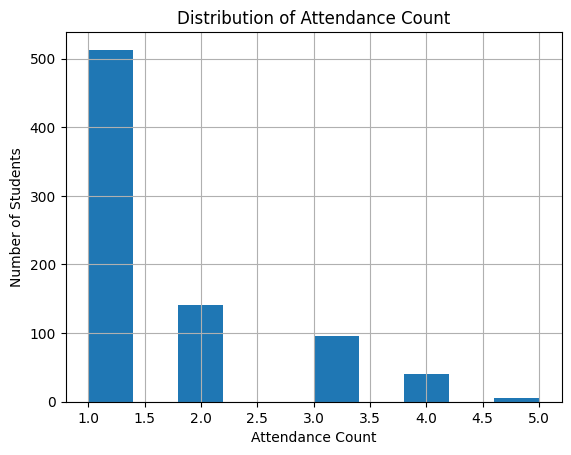

In [32]:
plt.figure()
attendance_count['attendance_count'].hist()
plt.title("Distribution of Attendance Count")
plt.xlabel("Attendance Count")
plt.ylabel("Number of Students")
plt.show()


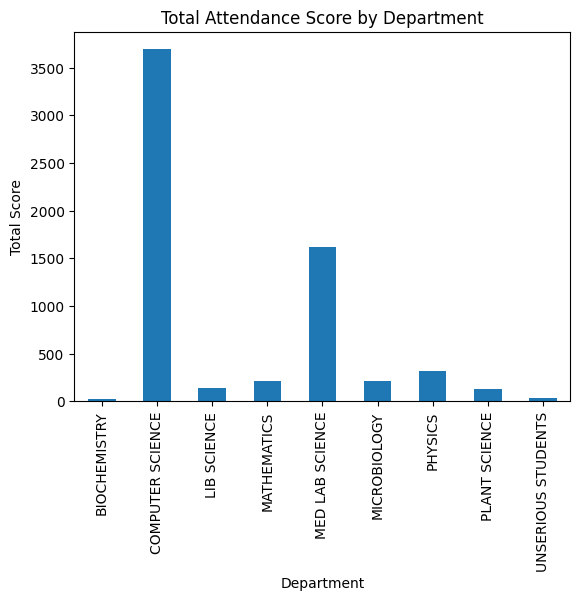

In [33]:
#  Attendance score by department
plt.figure()
attendance_count.groupby('department')['attendance_score'].sum().plot(kind='bar')
plt.title("Total Attendance Score by Department")
plt.xlabel("Department")
plt.ylabel("Total Score")
plt.show()


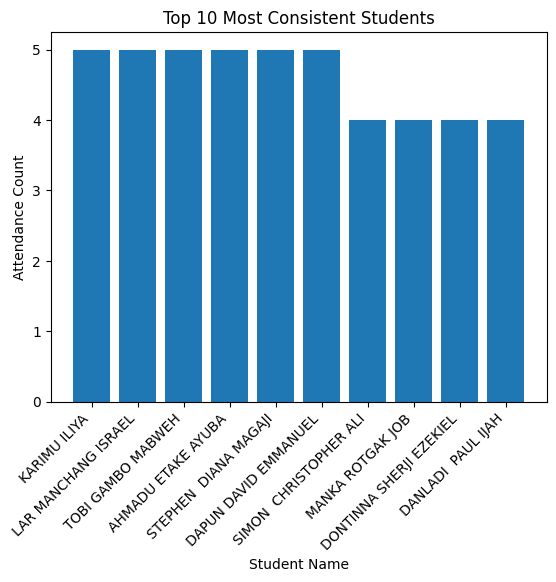

In [34]:

# Top 10 most consistent students
top_students = attendance_count.sort_values(
    by='attendance_count',
    ascending=False
).head(10)

plt.figure()
plt.bar(top_students['full_name'], top_students['attendance_count'])
plt.title("Top 10 Most Consistent Students")
plt.xlabel("Student Name")
plt.ylabel("Attendance Count")
plt.xticks(rotation=45, ha='right')
plt.show()



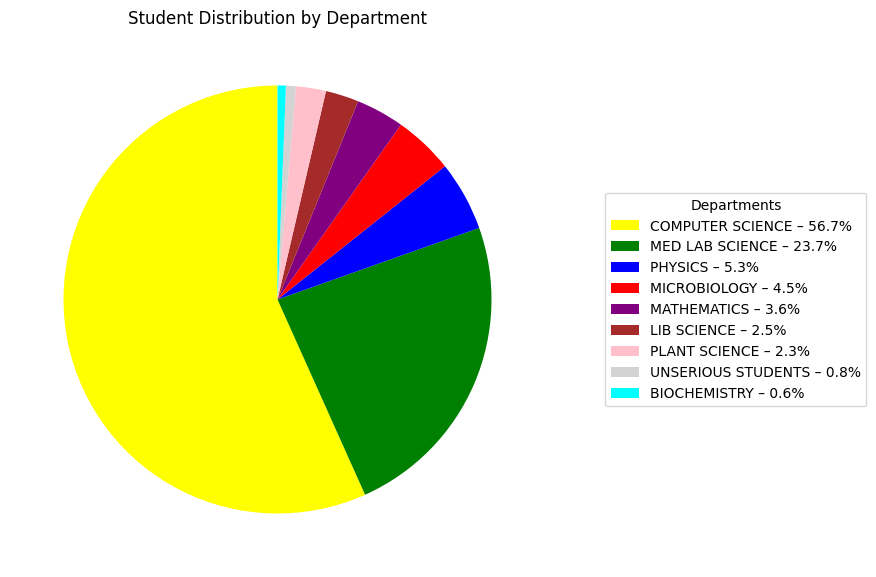

In [35]:

dept_counts = attendance_count['department'].value_counts()


percentages = (dept_counts / dept_counts.sum()) * 100

# Define colors for each department
colors = {
    'COMPUTER SCIENCE': 'yellow',
    'MED LAB SCIENCE': 'green',
    'PHYSICS': 'blue',
    'MICROBIOLOGY': 'red',
    'MATHEMATICS': 'purple',
    'LIB SCIENCE': 'brown',
    'PLANT SCIENCE': 'pink',
    'INDUSTRIAL STUDENTS': 'gray',
    'BIOCHEMISTRY': 'cyan'
}

# Match colors to departments
pie_colors = [colors.get(dept, 'lightgray') for dept in dept_counts.index]


plt.figure(figsize=(9, 9))


plt.pie(
    dept_counts,
    colors=pie_colors,
    startangle=90
)


plt.title("Student Distribution by Department")

# Create legend labels with percentages
legend_labels = [
    f"{dept} – {percentages[dept]:.1f}%"
    for dept in dept_counts.index
]

# Legend outside the chart
plt.legend(
    legend_labels,
    title="Departments",
    loc="center left",
    bbox_to_anchor=(1.1, 0.5)
)

plt.tight_layout()
plt.show()



## Conclusion
This notebook:
- Cleans attendance data  
- Computes attendance metrics  
- Exports department-level reports  
- Generates multiple insightful visualizations  

**#Data Science # Machine Learning** using pandas and matplotlib.
